# Classification of UCI Wine Quality (Red + White) - Decision Tree

Design and Creative Technologies, Torrens University

- **Student:** Luis Guilherme de Barros Andrade Faria - A00187785
- **Subject Name:** Machine Learning
- **Subject Code:** MLN 601
- **Title:** Binary Classification of Wine Quality with a Decision Tree
- **Lecturer:** Dr. Kamran Shaukat
- **Assessment No.:** 2
- **Date:** July 2026

| Field | Value |
|---|---|
| Dataset | UCI Wine Quality - red + white combined (Cortez et al., 2009) |
| Task | Binary classification: low (quality < 6) vs high (quality >= 6) |
| Algorithm | Decision Tree classifier (tuned) + Logistic Regression comparator |
| Tuning | GridSearchCV, 5-fold cross-validation, scoring = ROC AUC |
| Evaluation | AUC-ROC curve, confusion matrix, precision / recall / F1 |
| Methodology | CRISP-DM |

This notebook follows the six CRISP-DM stages to classify a wine as **high** or **low**
quality from its physicochemical measurements. Assessment 1 modelled the quality score as
regression; this brief revisits the same data as **classification**, tuning a Decision
Tree judged primarily on the **AUC-ROC** curve.

> Quality is a subjective, ordinal score, so the classifier is framed as an
> **interpretable decision-support tool** that flags likely low-quality batches for human
> review, not a replacement for expert tasting.

---

## 1. Business Understanding

Wine producers and distributors want a fast, low-cost screen that flags batches likely to
score poorly with tasters, so limited expert time is spent where it matters. The
**business question** for this assessment is therefore: *can a wine be classified as high
or low quality from routine physicochemical lab measurements alone?*

The UCI Wine Quality dataset records 11 physicochemical traits (acidity, residual sugar,
alcohol, and so on) and an expert **quality** score from 0-10 for red and white *vinho
verde* wines (Cortez et al., 2009). Following the brief, the continuous score is collapsed
into a **binary target**: a wine scoring **below 6 is "low" (class 1)** and a wine scoring
**6 or above is "high" (class 0)**. Class 1 (low) is treated as the *positive* class
because flagging weak batches is the action of interest.

Success is defined relative to a naive baseline that always predicts the majority class. A
useful model must beat that floor and, more importantly, achieve a high **AUC-ROC** - the
chance it ranks a random low-quality wine above a random high-quality one - since AUC is
threshold-independent and robust to class imbalance. The output supports, but does not
replace, human quality control.

## 2. Data Understanding

This stage acquires the data, checks its structure and quality, and explores the
relationships between the physicochemical features and wine quality. The red and white
files are loaded from the UCI repository (or a local copy) and concatenated into one frame
with a `wine_type` indicator (1 = red, 0 = white), giving a single, larger sample of
roughly 6,500 wines for the classifier to learn from.

In [1]:
import os
import warnings

# Silence sklearn/joblib parallel UserWarnings so they cannot flood the exported
# PDF. n_jobs=1 in the grid search below means no worker processes spawn either.
os.environ["PYTHONWARNINGS"] = "ignore"
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.linear_model import LogisticRegression
from sklearn.dummy import DummyClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                             f1_score, roc_auc_score, roc_curve,
                             confusion_matrix, ConfusionMatrixDisplay,
                             classification_report)

sns.set_theme(style="whitegrid")
RANDOM_STATE = 42

In [2]:
from pathlib import Path

# Resolve project folders relative to the notebook location so the same notebook
# runs locally and on Colab/Azure without editing paths.
NB_DIR = Path.cwd()
BASE_DIR = NB_DIR.parent if NB_DIR.name == "notebook" else NB_DIR
OUTPUT_DIR = BASE_DIR / "outputs"
FIG_DIR = OUTPUT_DIR / "figures"
FIG_DIR.mkdir(parents=True, exist_ok=True)

UCI_BASE = ("https://archive.ics.uci.edu/ml/machine-learning-databases/"
            "wine-quality/")


def load_wine(colour):
    fname = f"winequality-{colour}.csv"
    candidates = [BASE_DIR / "dataset" / fname,
                  NB_DIR / "dataset" / fname,
                  NB_DIR / fname]
    local = next((p for p in candidates if p.exists()), None)
    if local is not None:
        print("Loading local:", local)
        return pd.read_csv(local, sep=";")
    print("Loading from UCI URL:", UCI_BASE + fname)
    return pd.read_csv(UCI_BASE + fname, sep=";")


red = load_wine("red")
white = load_wine("white")
red["wine_type"] = 1    # 1 = red
white["wine_type"] = 0  # 0 = white
df = pd.concat([red, white], ignore_index=True)

print("Red:", red.shape, "| White:", white.shape, "| Combined:", df.shape)
df.head()

Loading local: /Users/luisfaria/Desktop/sEngineer/masters_SWEAI/2026-T2/MLN/assignments/Assessment2/dataset/winequality-red.csv
Loading local: /Users/luisfaria/Desktop/sEngineer/masters_SWEAI/2026-T2/MLN/assignments/Assessment2/dataset/winequality-white.csv
Red: (1599, 13) | White: (4898, 13) | Combined: (6497, 13)


,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality,wine_type
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5,1
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,5,1
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,5,1
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,6,1
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5,1


In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 6497 entries, 0 to 6496
Data columns (total 13 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   fixed acidity         6497 non-null   float64
 1   volatile acidity      6497 non-null   float64
 2   citric acid           6497 non-null   float64
 3   residual sugar        6497 non-null   float64
 4   chlorides             6497 non-null   float64
 5   free sulfur dioxide   6497 non-null   float64
 6   total sulfur dioxide  6497 non-null   float64
 7   density               6497 non-null   float64
 8   pH                    6497 non-null   float64
 9   sulphates             6497 non-null   float64
 10  alcohol               6497 non-null   float64
 11  quality               6497 non-null   int64  
 12  wine_type             6497 non-null   int64  
dtypes: float64(11), int64(2)
memory usage: 660.0 KB


In [4]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
fixed acidity,6497.0,7.215307,1.296434,3.80000,6.40000,7.00000,7.70000,15.90000
volatile acidity,6497.0,0.339666,0.164636,0.08000,0.23000,0.29000,0.40000,1.58000
citric acid,6497.0,0.318633,0.145318,0.00000,0.25000,0.31000,0.39000,1.66000
residual sugar,6497.0,5.443235,4.757804,0.60000,1.80000,3.00000,8.10000,65.80000
chlorides,6497.0,0.056034,0.035034,0.00900,0.03800,0.04700,0.06500,0.61100
free sulfur dioxide,6497.0,30.525319,17.749400,1.00000,17.00000,29.00000,41.00000,289.00000
total sulfur dioxide,6497.0,115.744574,56.521855,6.00000,77.00000,118.00000,156.00000,440.00000
density,6497.0,0.994697,0.002999,0.98711,0.99234,0.99489,0.99699,1.03898
pH,6497.0,3.218501,0.160787,2.72000,3.11000,3.21000,3.32000,4.01000
sulphates,6497.0,0.531268,0.148806,0.22000,0.43000,0.51000,0.60000,2.00000


In [5]:
print("Missing values per column:")
print(df.isna().sum().to_string())
print("\nDuplicate rows:", int(df.duplicated().sum()))

Missing values per column:
fixed acidity           0
volatile acidity        0
citric acid             0
residual sugar          0
chlorides               0
free sulfur dioxide     0
total sulfur dioxide    0
density                 0
pH                      0
sulphates               0
alcohol                 0
quality                 0
wine_type               0

Duplicate rows: 1177


### 2.2 The classification target

The brief defines the target by thresholding the expert score: **quality < 6 -> "low" (1)**
and **quality >= 6 -> "high" (0)**. Encoding low quality as the positive class (1) keeps
the model's "positive" prediction aligned with the business action - flagging a batch for
review. The cell below derives the `quality_label` column and shows the class balance. The
split is uneven (more high-quality wines), which is exactly why **accuracy alone is
misleading** and the evaluation leans on AUC-ROC and per-class recall.

Class counts:
quality_label
high (>=6)    4113
low (<6)      2384

Class proportions:
quality_label
high (>=6)    0.633
low (<6)      0.367


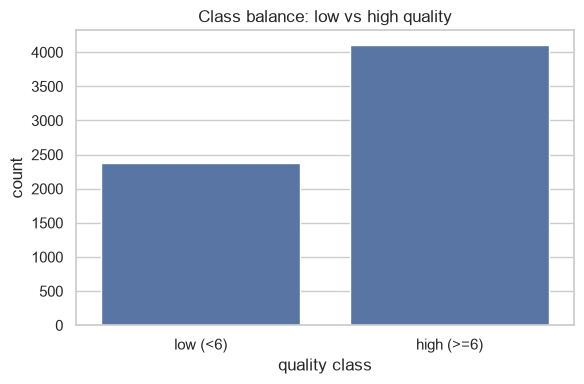

In [6]:
# Brief's encoding: quality < 6 -> low (1, positive class); quality >= 6 -> high (0)
df["quality_label"] = (df["quality"] < 6).astype(int)
label_names = {0: "high (>=6)", 1: "low (<6)"}
df["quality_name"] = df["quality_label"].map(label_names)

counts = df["quality_label"].value_counts().sort_index()
print("Class counts:")
print(counts.rename(index=label_names).to_string())
print("\nClass proportions:")
print((counts / len(df)).round(3).rename(index=label_names).to_string())

plt.figure(figsize=(6, 4))
sns.countplot(x="quality_name", data=df, order=["low (<6)", "high (>=6)"])
plt.title("Class balance: low vs high quality")
plt.xlabel("quality class")
plt.ylabel("count")
plt.tight_layout()
plt.savefig(FIG_DIR / "v1_class_balance.png", dpi=120)
plt.show()

### 2.3 Feature relationships

The correlation heatmap and the seaborn **pairplot** (required by the brief) show how the
features move with each other and with quality. `alcohol` shows the clearest separation
between high and low wines, while several acidity and sulfur-dioxide measures are
correlated with each other - a hint that a non-linear model able to capture interactions
may do well.

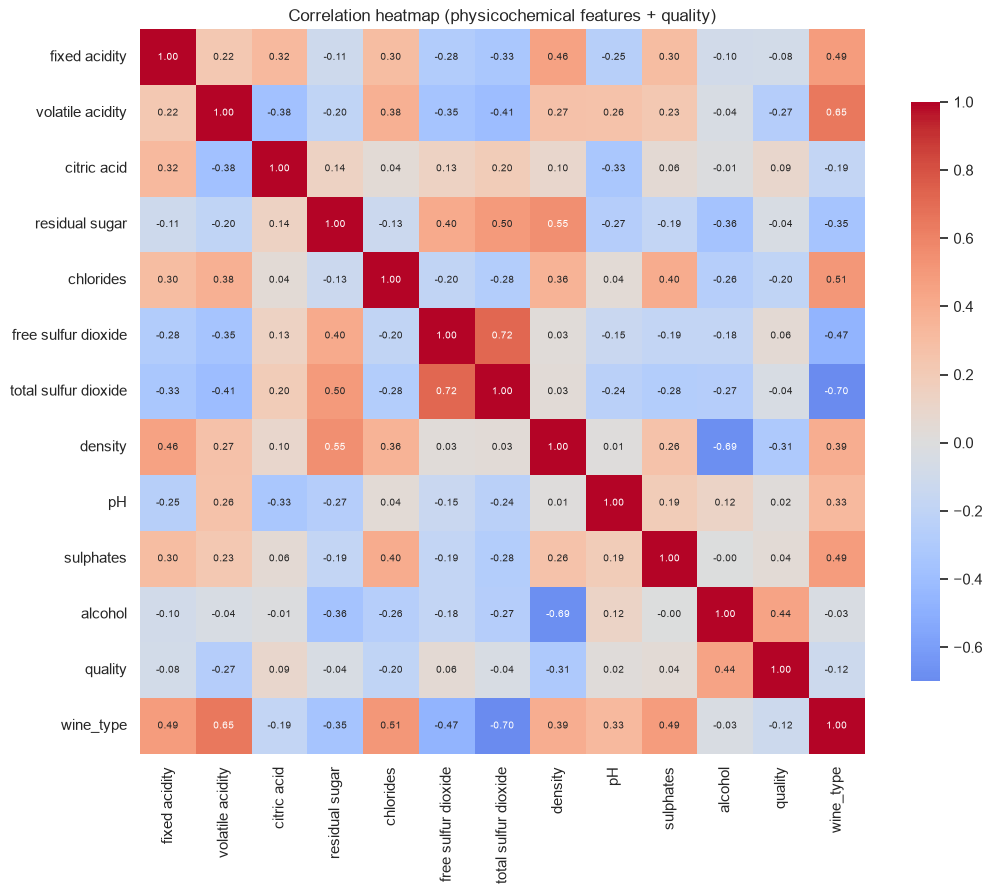

In [7]:
plt.figure(figsize=(11, 9))
corr = df.drop(columns=["quality_label"]).corr(numeric_only=True)
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", center=0,
            square=True, cbar_kws={"shrink": 0.8}, annot_kws={"size": 7})
plt.title("Correlation heatmap (physicochemical features + quality)")
plt.tight_layout()
plt.savefig(FIG_DIR / "v1_corr_heatmap.png", dpi=120)
plt.show()

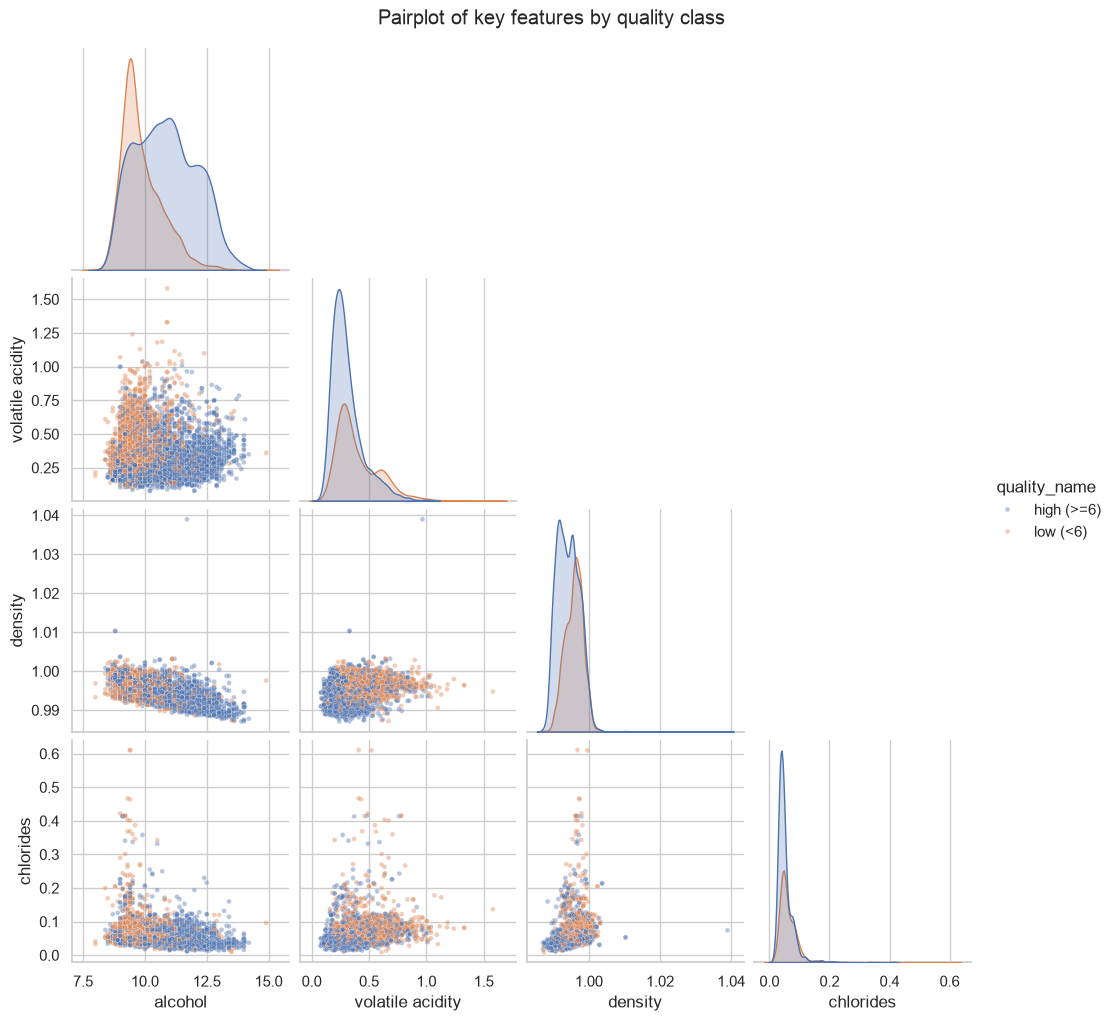

In [8]:
pair_cols = ["alcohol", "volatile acidity", "density", "chlorides"]
g = sns.pairplot(df, vars=pair_cols, hue="quality_name",
                 hue_order=["high (>=6)", "low (<6)"], corner=True,
                 plot_kws={"alpha": 0.4, "s": 12}, diag_kind="kde")
g.fig.suptitle("Pairplot of key features by quality class", y=1.02)
g.savefig(FIG_DIR / "v1_pairplot.png", dpi=110)
plt.show()

**Interpretation.** Three things stand out. First, there are **no missing values**, so no
imputation is needed. Second, `alcohol` has the strongest positive association with high
quality and `volatile acidity` the clearest negative one, matching wine-science intuition.
Third, several features are **mutually correlated** (for example `free sulfur dioxide` with
`total sulfur dioxide`, and `density` with `alcohol` and `residual sugar`). Strong
collinearity destabilises a linear model's coefficients but barely affects a Decision Tree,
which splits one feature at a time on thresholds. The pairplot also shows the two classes
**overlap heavily** - no single feature separates them cleanly - so we should expect a
good-but-imperfect classifier rather than a near-perfect one.

## 3. Data Preparation

Preparation here is light because the data is already clean and numeric. Three steps
matter. **(1) Feature/target split:** `quality` and the derived label columns are removed
from the feature matrix `X` so the original score cannot leak into training; `wine_type` is
kept as an informative feature. **(2) Train/test split:** an 80/20 **stratified** split
preserves the high/low ratio in both partitions, which matters under class imbalance, with
a fixed `random_state` for reproducibility. **(3) Scaling:** a Decision Tree is
**scale-invariant** (it compares each feature against a threshold), so it needs no scaling;
the Logistic Regression comparator *does*, so its `StandardScaler` is placed **inside a
Pipeline**. That way the scaler is refit on each training fold during cross-validation and
never sees the validation rows - preventing the data leakage that would otherwise inflate
the scores. The earlier check flagged **1,177 duplicate rows**; with no unique
wine ID these may be distinct wines with identical readings, so they are kept to avoid
discarding valid samples.

In [9]:
LEAK_COLS = ["quality", "quality_label", "quality_name"]
feature_cols = [c for c in df.columns if c not in LEAK_COLS]
X = df[feature_cols]
y = df["quality_label"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=RANDOM_STATE, stratify=y)

print("Train:", X_train.shape, "| Test:", X_test.shape)
print("\nTrain class balance:")
print(y_train.value_counts(normalize=True).round(3).rename(index=label_names).to_string())
print("Test class balance:")
print(y_test.value_counts(normalize=True).round(3).rename(index=label_names).to_string())
print("\nFeatures used (%d):" % len(feature_cols), feature_cols)

Train: (5197, 12) | Test: (1300, 12)

Train class balance:
quality_label
high (>=6)    0.633
low (<6)      0.367
Test class balance:
quality_label
high (>=6)    0.633
low (<6)      0.367

Features used (12): ['fixed acidity', 'volatile acidity', 'citric acid', 'residual sugar', 'chlorides', 'free sulfur dioxide', 'total sulfur dioxide', 'density', 'pH', 'sulphates', 'alcohol', 'wine_type']


## 4. Modelling

Four models are compared so the tuned Decision Tree can be read in context:

1. **Majority-class baseline** (`DummyClassifier`) - the floor every real model must beat;
   its AUC sits at ~0.5 by construction.
2. **Default Decision Tree** - an untuned tree, to show what tuning actually buys.
3. **Tuned Decision Tree** - the required model. A `GridSearchCV` searches `max_depth`,
   `min_samples_leaf`, `criterion` (gini vs entropy) and `class_weight` (none vs balanced)
   using **5-fold cross-validation**, scored on **ROC AUC**. An unconstrained tree grows
   until its leaves are pure and overfits; these hyperparameters prune that complexity.
4. **Logistic Regression** - a linear probabilistic comparator (Module 8). The brief asks
   for one technique, so this is included only as **optional context**: a straight-line
   decision boundary to contrast with the tree's axis-aligned splits.

Every estimator uses a fixed seed and `n_jobs=1` for deterministic, warning-free runs.
Cross-validation tunes on the training set only; the held-out test set is touched once, in
Evaluation.

In [10]:
# 1) Majority-class baseline
dummy = DummyClassifier(strategy="most_frequent")
dummy.fit(X_train, y_train)

# 2) Default (untuned) Decision Tree
dt_default = DecisionTreeClassifier(random_state=RANDOM_STATE)
dt_default.fit(X_train, y_train)

# 3) Tuned Decision Tree - the required model
param_grid = {
    "max_depth": [3, 4, 5, 6, 8, None],
    "min_samples_leaf": [1, 5, 10, 20],
    "criterion": ["gini", "entropy"],
    "class_weight": [None, "balanced"],
}
grid = GridSearchCV(
    DecisionTreeClassifier(random_state=RANDOM_STATE),
    param_grid, scoring="roc_auc", cv=5, n_jobs=1)
grid.fit(X_train, y_train)
dt_best = grid.best_estimator_
print("Best params:", grid.best_params_)
print("Best CV ROC AUC: %.3f" % grid.best_score_)

# 4) Logistic Regression comparator (needs scaling -> Pipeline)
logreg = Pipeline([
    ("scaler", StandardScaler()),
    ("clf", LogisticRegression(max_iter=2000, random_state=RANDOM_STATE)),
])
logreg.fit(X_train, y_train)

models = {
    "Majority baseline": dummy,
    "Decision Tree (default)": dt_default,
    "Decision Tree (tuned)": dt_best,
    "Logistic Regression": logreg,
}
print("\nFitted models:", list(models))

Best params: {'class_weight': None, 'criterion': 'gini', 'max_depth': 6, 'min_samples_leaf': 20}
Best CV ROC AUC: 0.796

Fitted models: ['Majority baseline', 'Decision Tree (default)', 'Decision Tree (tuned)', 'Logistic Regression']


### 4.2 Selected hyperparameters

`GridSearchCV` refits the best configuration on the full training set. The chosen
parameters below balance depth against generalisation - a moderate `max_depth` with a
minimum leaf size large enough to stop the tree memorising individual wines. These values
are saved to `outputs/` for traceability.

In [11]:
best_params = pd.Series(grid.best_params_, dtype="object").astype(str)
best_params.loc["cv_roc_auc"] = round(grid.best_score_, 4)
best_params.to_csv(OUTPUT_DIR / "tree_best_params_v1.csv", header=["value"])
best_params.to_frame("value")

,value
class_weight,NaN
criterion,gini
max_depth,6
min_samples_leaf,20
cv_roc_auc,0.7959


## 5. Evaluation

The models are now judged on the **held-out test set** they never saw during tuning.
Because the classes are imbalanced, no single number tells the whole story, so several
complementary metrics are reported:

- **AUC-ROC** - the headline metric. It measures how well the model *ranks* low-quality
  wines above high-quality ones across all thresholds, independent of where the decision
  cut-off is placed, which makes it robust to imbalance.
- **Accuracy** - intuitive but misleading here: always predicting "high" already scores
  reasonably, so accuracy must be read against the baseline.
- **Precision, recall and F1 for the low class** - whether the model actually *catches* the
  weak batches it is meant to flag, and how often its flags are correct.
- **Confusion matrix** - the raw counts behind those rates.

The ROC curves are overlaid (diagonal = random guessing), and the decision-tree plot and
feature-importance chart make the model's logic transparent - a white-box advantage for a
decision-support tool.

In [12]:
def class_metrics(model, X_te, y_te):
    pred = model.predict(X_te)
    if hasattr(model, "predict_proba"):
        proba = model.predict_proba(X_te)[:, 1]   # P(class 1 = low)
    else:
        proba = model.decision_function(X_te)
    pos = dict(pos_label=1, zero_division=0)
    return {
        "accuracy": accuracy_score(y_te, pred),
        "precision_low": precision_score(y_te, pred, **pos),
        "recall_low": recall_score(y_te, pred, **pos),
        "f1_low": f1_score(y_te, pred, **pos),
        "roc_auc": roc_auc_score(y_te, proba),
    }

results = pd.DataFrame(
    {name: class_metrics(m, X_test, y_test) for name, m in models.items()}
).T.round(3)
results.index.name = "model"
results.to_csv(OUTPUT_DIR / "model_metrics_v1.csv")
results

,accuracy,precision_low,recall_low,f1_low,roc_auc
model,,,,,
Majority baseline,0.633,0.000,0.000,0.000,0.500
Decision Tree (default),0.786,0.702,0.725,0.713,0.773
Decision Tree (tuned),0.737,0.637,0.656,0.647,0.809
Logistic Regression,0.752,0.700,0.568,0.627,0.814


In [13]:
report = classification_report(
    y_test, dt_best.predict(X_test),
    target_names=["high (>=6)", "low (<6)"],
    output_dict=True, zero_division=0)
report_df = pd.DataFrame(report).T.round(3)
report_df.to_csv(OUTPUT_DIR / "classification_report_v1.csv")
report_df

,precision,recall,f1-score,support
high (>=6),0.797,0.784,0.790,823.000
low (<6),0.637,0.656,0.647,477.000
accuracy,0.737,0.737,0.737,0.737
macro avg,0.717,0.720,0.719,1300.000
weighted avg,0.739,0.737,0.738,1300.000


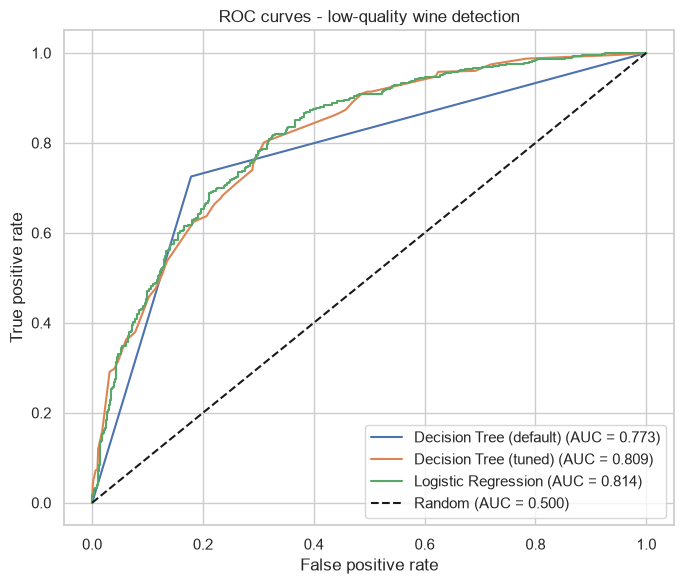

In [14]:
plt.figure(figsize=(7, 6))
for name, m in models.items():
    if name == "Majority baseline":
        continue
    proba = m.predict_proba(X_test)[:, 1]
    fpr, tpr, _ = roc_curve(y_test, proba, pos_label=1)
    auc = roc_auc_score(y_test, proba)
    plt.plot(fpr, tpr, label=f"{name} (AUC = {auc:.3f})")
plt.plot([0, 1], [0, 1], "k--", label="Random (AUC = 0.500)")
plt.xlabel("False positive rate")
plt.ylabel("True positive rate")
plt.title("ROC curves - low-quality wine detection")
plt.legend(loc="lower right")
plt.tight_layout()
plt.savefig(FIG_DIR / "v1_roc_curves.png", dpi=120)
plt.show()

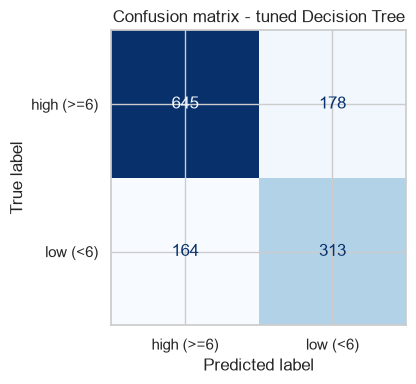

In [15]:
fig, ax = plt.subplots(figsize=(5, 4))
cm = confusion_matrix(y_test, dt_best.predict(X_test))
ConfusionMatrixDisplay(cm, display_labels=["high (>=6)", "low (<6)"]).plot(
    ax=ax, cmap="Blues", colorbar=False)
ax.set_title("Confusion matrix - tuned Decision Tree")
plt.tight_layout()
plt.savefig(FIG_DIR / "v1_confusion_matrix.png", dpi=120)
plt.show()

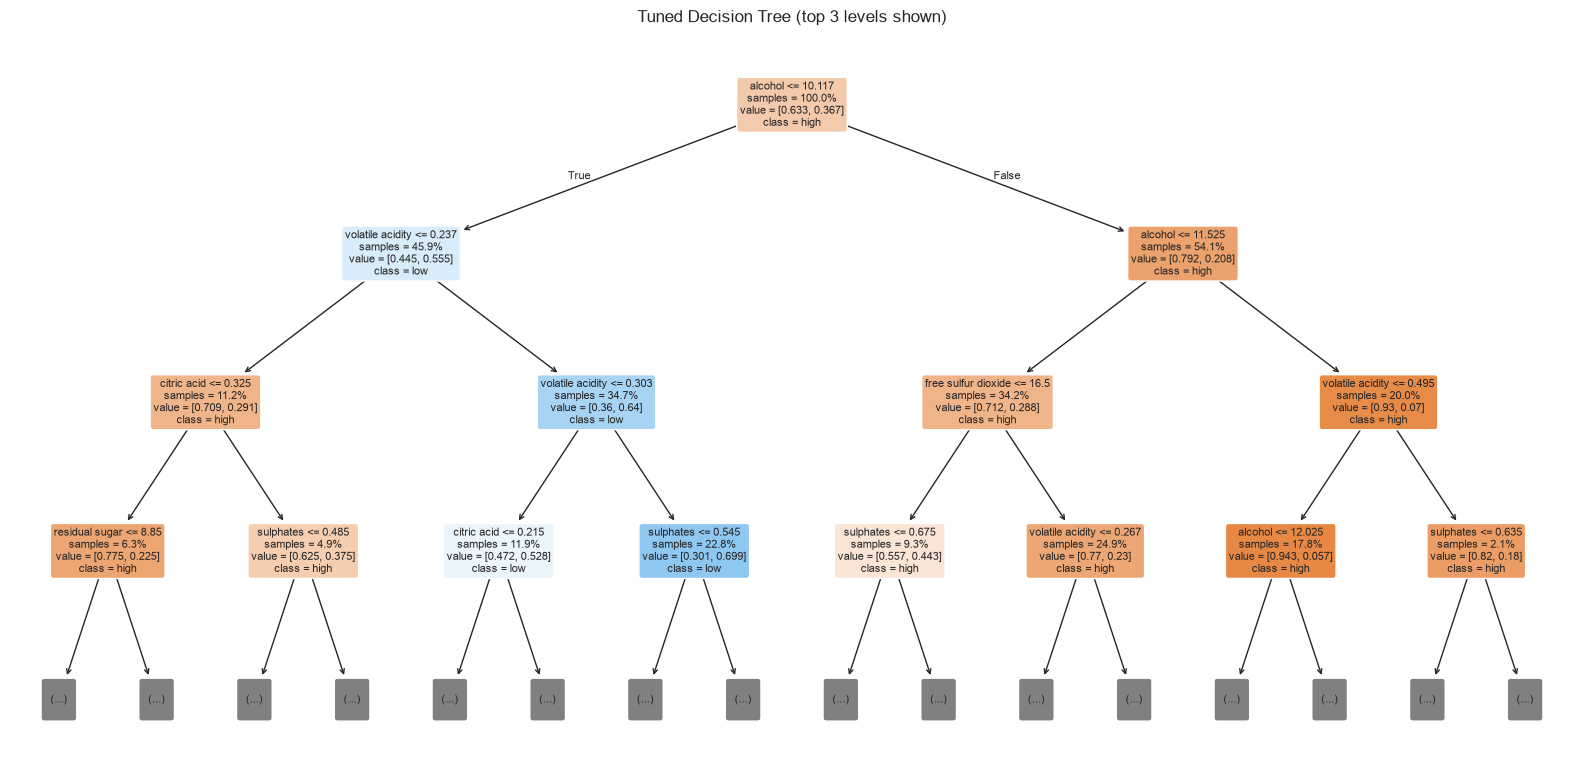

In [16]:
plt.figure(figsize=(16, 8))
plot_tree(dt_best, feature_names=feature_cols, class_names=["high", "low"],
          filled=True, rounded=True, max_depth=3, fontsize=8,
          impurity=False, proportion=True)
plt.title("Tuned Decision Tree (top 3 levels shown)")
plt.tight_layout()
plt.savefig(FIG_DIR / "v1_decision_tree.png", dpi=110)
plt.show()

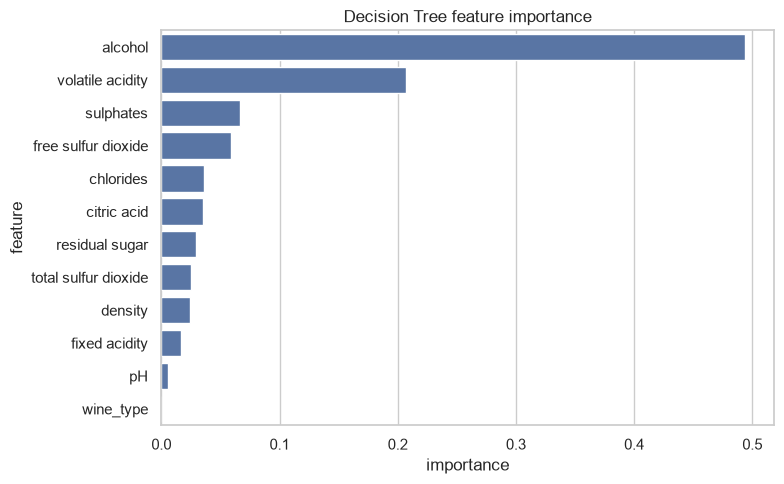

,feature,importance
0,alcohol,0.493657
1,volatile acidity,0.207295
2,sulphates,0.066892
3,free sulfur dioxide,0.059251
4,chlorides,0.036338
5,citric acid,0.035003
6,residual sugar,0.029429
7,total sulfur dioxide,0.025249
8,density,0.024245
9,fixed acidity,0.016697


In [17]:
importance = (pd.DataFrame({"feature": feature_cols,
                            "importance": dt_best.feature_importances_})
              .sort_values("importance", ascending=False)
              .reset_index(drop=True))
importance.to_csv(OUTPUT_DIR / "feature_importance_v1.csv", index=False)

plt.figure(figsize=(8, 5))
sns.barplot(x="importance", y="feature", data=importance)
plt.title("Decision Tree feature importance")
plt.tight_layout()
plt.savefig(FIG_DIR / "v1_feature_importance.png", dpi=120)
plt.show()
importance

**Interpretation.** The tuned Decision Tree reaches a test **AUC of 0.809**, far above the
majority baseline (0.500) and essentially level with the Logistic Regression comparator
(0.814). Tuning raised the tree's AUC over the untuned default (0.773) by pruning it back
(`max_depth=6`, `min_samples_leaf=20`) from a fully grown, overfit tree - though it trades
a little raw accuracy (0.74 vs 0.79) for that better, more honest ranking. The confusion
matrix shows the model confirms high-quality wines (recall 0.78) more reliably than it
catches every low-quality one (recall 0.66) - the residual cost of class imbalance and
heavy class overlap. **Feature importance** is dominated by `alcohol` (0.49) and `volatile
acidity` (0.21), echoing the EDA and matching wine chemistry, while `wine_type` adds almost
nothing. With an AUC near 0.81 the model is a useful screen but far from perfect: it ranks
wines well, yet should not auto-reject a batch on its own.

## 6. Deployment / Lessons Learned

In CRISP-DM, deployment for this assessment means reflection rather than a production
release. **What worked:** framing the problem as binary classification made the Decision
Tree a natural, interpretable fit, and AUC-ROC gave an honest read of performance under
imbalance, where accuracy would have flattered a lazy "always high" model. The white-box
tree and feature-importance chart make the result explainable to a non-technical
stakeholder - a real advantage for quality control.

**What was harder:** the classes overlap heavily in feature space, so no amount of tuning
produced a clean separation; the model is a *screen*, not an oracle. The imbalance shows up
as weaker recall on the minority "low" class (0.66 vs 0.78); the grid search explored
`class_weight="balanced"` to counter it, but ultimately favoured a shallower, pruned tree
that maximised AUC.

**What I would do differently next time:** test an ensemble (Random Forest or gradient
boosting) to see how much a single tree leaves on the table; tune the decision threshold
explicitly to the cost of missing a bad batch rather than defaulting to 0.5; and engineer
interaction features the tree currently has to discover on its own. The honest lesson
echoes Assessment 1 - **model and framing choices, plus careful evaluation, matter more
than raw data volume.**

---

## Academic Integrity Declaration

I declare that except where I have referenced, the work I am submitting for this assessment task is my own work. I have read and am aware of the Torrens University Australia Academic Integrity Policy and Procedure viewable online at http://www.torrens.edu.au/policies-and-forms

I am aware that I need to keep a copy of all submitted material and their drafts, and I will do so accordingly.

## Statement of Acknowledgement

I acknowledge that I have used the following AI tool(s) in the creation of this report:
- Anthropic Claude Opus 4.8
- OpenAI ChatGPT Codex 5.5

Both tools were used to assist with understanding ML concepts, structuring the technical pipeline, improving clarity of academic language, and supporting APA 7th referencing conventions.

Prompt examples:
1. "Explain how to convert the UCI wine quality score into a binary classification target and why AUC-ROC is the right metric when the classes are imbalanced."
2. "How do I tune a scikit-learn DecisionTreeClassifier with GridSearchCV (max_depth, min_samples_leaf, criterion, class_weight) using 5-fold cross-validation scored on ROC AUC, without leaking the test set?"
3. "Why is a Decision Tree scale-invariant while Logistic Regression needs a StandardScaler, and how should I place the scaler in a Pipeline to avoid data leakage during cross-validation?"

I confirm that the use of these tools has been in accordance with the Torrens University Australia Academic Integrity Policy and TUA, Think and MDS's Position Paper on the Use of AI. I confirm that the final output is authored by me and represents my own critical thinking, analysis, and synthesis of sources. I take full responsibility for the final content of this report.

## References

Chapman, P., Clinton, J., Kerber, R., Khabaza, T., Reinartz, T., Shearer, C., & Wirth, R. (2000). *CRISP-DM 1.0: Step-by-step data mining guide*. SPSS Inc. https://www.the-modeling-agency.com/crisp-dm.pdf

Cortez, P., Cerdeira, A., Almeida, F., Matos, T., & Reis, J. (2009). Modeling wine preferences by data mining from physicochemical properties. *Decision Support Systems, 47*(4), 547-553. https://doi.org/10.1016/j.dss.2009.05.016

Pedregosa, F., Varoquaux, G., Gramfort, A., Michel, V., Thirion, B., Grisel, O., Blondel, M., Prettenhofer, P., Weiss, R., Dubourg, V., Vanderplas, J., Passos, A., Cournapeau, D., Brucher, M., Perrot, M., & Duchesnay, E. (2011). Scikit-learn: Machine learning in Python. *Journal of Machine Learning Research, 12*, 2825-2830.

University of California, Irvine. (n.d.). *Wine quality data set*. UCI Machine Learning Repository. Retrieved July 2, 2026, from https://archive.ics.uci.edu/dataset/186/wine+quality